In [8]:
import sys
sys.path.append("../src")

import pandas as pd

from portfolio_optimizer.data_loader import (
    download_prices,
    compute_returns
)

from portfolio_optimizer.optimization import baseline_lp

from portfolio_optimizer.plots import plot_weights

[*********************100%***********************]  4 of 4 completed


  Asset  Weight
0   SPY    0.30
1   QQQ    0.35
2   TLT    0.35
3   GLD    0.00
Expected Portfolio Return: 0.1413


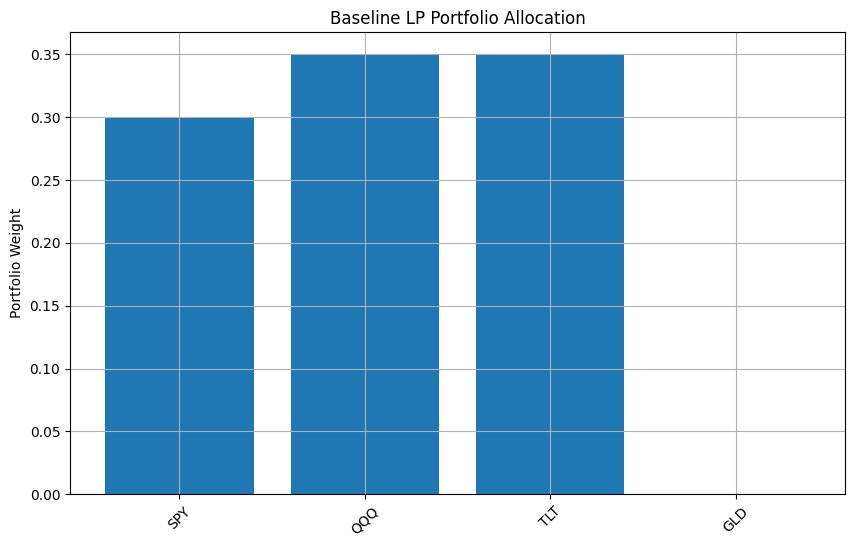

In [9]:
tickers = ["SPY", "QQQ", "TLT", "GLD"]

prices = download_prices(
    tickers,
    "2015-01-01",
    "2025-01-01"
)

returns, mean_returns, risk = compute_returns(prices)

weights, portfolio_return = baseline_lp(mean_returns)

weights_df = pd.DataFrame({
    "Asset": tickers,
    "Weight": weights
})

weights_df["Weight"] = weights_df["Weight"].round(4)

print(weights_df)

print(f"Expected Portfolio Return: {portfolio_return:.4f}")

plot_weights(
    weights,
    tickers,
    "Baseline LP Portfolio Allocation"
)